In [45]:
from pathlib import Path
from typing import cast

import geopandas as gpd
import osmnx as ox

from shapely import Polygon

In [46]:
ox.settings.all_oneway = True

In [47]:
PLACE_NAME = "O'Hare, Chicago, Illinois, USA"
BASE_PATH = Path(".").resolve().absolute()
DATA_BASE_PATH = BASE_PATH / "data"
BOUNDARY_PATH = BASE_PATH / "boundary.geojson"

<Axes: >

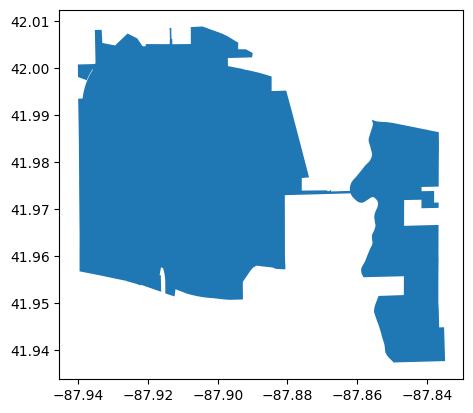

In [48]:
gdf = ox.geocode_to_gdf(PLACE_NAME)
gdf.plot()

In [49]:
G = ox.graph_from_polygon(
    cast(Polygon, gdf.geometry[0]),
    network_type="drive", # drive_service
    simplify=False,
    retain_all=False,
    # custom_filter=(
    #     '["highway"]["highway"!~"footway|cycleway|path|pedestrian|steps|corridor|elevator|proposed|construction|busway"]'
    # ),
)
G

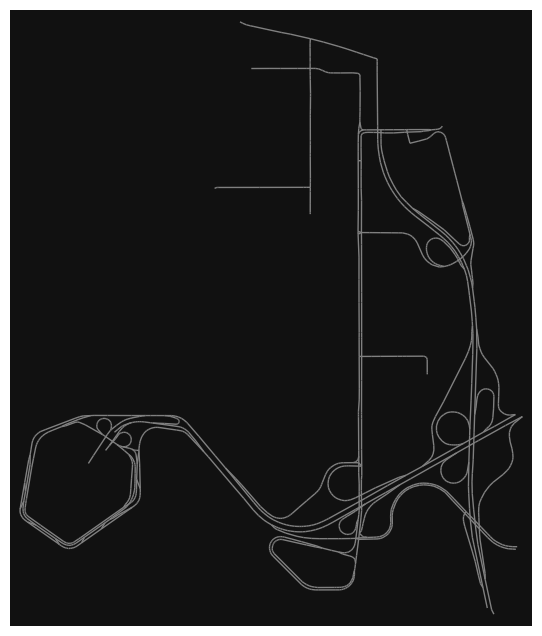

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [50]:
ox.plot_graph(G, node_size=0, edge_color="gray")

In [51]:
nodes, edges = ox.graph_to_gdfs(G)
edges["highway"].value_counts()

highway
unclassified     614
motorway_link    313
tertiary         164
primary          122
motorway          91
primary_link      68
tertiary_link      7
Name: count, dtype: int64

In [52]:
nodes_wgs = nodes.to_crs(epsg=4326)
edges_wgs = edges.to_crs(epsg=4326)

In [53]:
nodes

,y,x,street_count,ref,highway,junction,geometry
osmid,,,,,,,
1153867776,41.988700,-87.879139,2,NaN,NaN,NaN,POINT (-87.87914 41.9887)
1153867781,41.982106,-87.881109,2,NaN,NaN,NaN,POINT (-87.88111 41.98211)
29786118,41.978712,-87.885730,2,NaN,NaN,NaN,POINT (-87.88573 41.97871)
1153867783,41.980169,-87.876436,2,NaN,NaN,NaN,POINT (-87.87644 41.98017)
1153867787,41.982272,-87.880415,2,NaN,NaN,NaN,POINT (-87.88042 41.98227)
...,...,...,...,...,...,...,...
1153867763,41.982229,-87.879610,2,NaN,NaN,NaN,POINT (-87.87961 41.98223)
1153867765,41.991735,-87.883228,2,NaN,NaN,NaN,POINT (-87.88323 41.99173)
1153867766,41.981473,-87.881054,2,NaN,NaN,NaN,POINT (-87.88105 41.98147)


In [54]:
edges_wgs["oneway"] = edges_wgs["oneway"].str.lower().isin(["true", "yes", "1"])
edges_wgs["oneway"]

u           v            key
1153867776  29839280     0      True
1153867781  1153867758   0      True
29786118    4686227143   0      True
1153867783  102857951    0      True
1153867787  102855121    0      True
                                ... 
1153867763  102855124    0      True
1153867765  29840722     0      True
1153867766  102855117    0      True
29786106    10023495265  0      True
1153867774  1153867839   0      True
Name: oneway, Length: 1379, dtype: bool

In [55]:
G = ox.graph_from_gdfs(nodes_wgs, edges_wgs)
G

In [56]:
ox.save_graph_xml(G, filepath=DATA_BASE_PATH / "ohare_network.osm.xml")
ox.save_graphml(G, filepath=DATA_BASE_PATH / "ohare_network.graphml")